In [23]:
import pypsa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
idx = pd.IndexSlice

c:\Users\lukas\miniforge3\envs\pypsa-earth\lib\site-packages\pypsa\networkclustering.py:16: UserWarning: The namespace `pypsa.networkclustering` is deprecated and will be removed in PyPSA v0.24. Please use `pypsa.clustering.spatial instead`. 
  warnings.warn(


In [17]:
path = Path.cwd() / 'clusterdata'

In [18]:
stop = pd.read_csv(
    path / 'gathered_storage_operation.csv', index_col=0, parse_dates=True, header=[0,1]
)

In [20]:
mp = pd.read_csv(
    path / 'gathered_marginal_prices.csv', index_col=0, parse_dates=True, header=[0,1]
)

In [22]:
charging = stop.clip(upper=0)
discharging = stop.clip(lower=0)

In [26]:
nat_charging = charging.loc[:, idx['national']]
rnp_charging = charging.loc[:, idx['nodal']]
nat_discharging = discharging.loc[:, idx['national']]
rnp_discharging = discharging.loc[:, idx['nodal']]

In [36]:
nat_mp = mp.loc[:, idx['national', 'GB']]
rnp_mp = mp.loc[:, idx['rnp2', 'GB']]

In [49]:
nat_charging_cost = nat_charging.multiply(nat_mp, axis=0).fillna(0) * 0.5
nat_discharging_revenue = nat_discharging.multiply(nat_mp, axis=0).fillna(0) * 0.5

rnp_charging_cost = rnp_charging.multiply(rnp_mp, axis=0).fillna(0) * 0.5
rnp_discharging_revenue = rnp_discharging.multiply(rnp_mp, axis=0).fillna(0) * 0.5

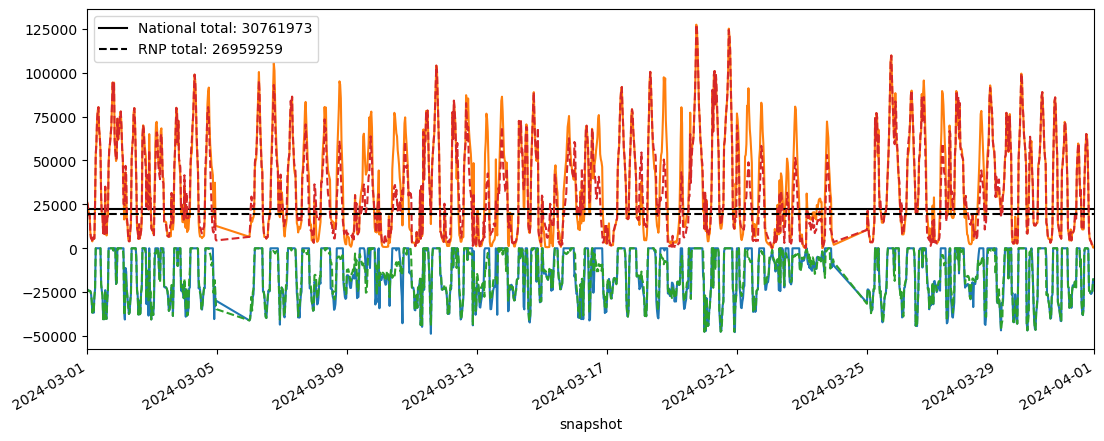

In [60]:
fig, ax = plt.subplots(1, 1, figsize=(13, 5))

start = pd.Timestamp('2024-03-01')
end = pd.Timestamp('2024-04-01')

mask = (nat_charging_cost.index >= start) & (nat_charging_cost.index < end)

nat_charging_cost.sum(axis=1).loc[mask].plot(ax=ax)
nat_discharging_revenue.sum(axis=1).loc[mask].plot(ax=ax)

ax.axhline(
    nat_charging_cost.sum(axis=1).loc[mask].mean() + nat_discharging_revenue.sum(axis=1).loc[mask].mean(),
    color='black',
    linestyle='-',
)

rnp_charging_cost.sum(axis=1).loc[mask].plot(ax=ax, ls='--')
rnp_discharging_revenue.sum(axis=1).loc[mask].plot(ax=ax, ls='--')

ax.axhline(
    rnp_charging_cost.sum(axis=1).loc[mask].mean() + rnp_discharging_revenue.sum(axis=1).loc[mask].mean(),
    color='black',
    linestyle='--',
)

# Add legend for the lines
ax.plot([], [], color='black', linestyle='-', label=f'National total: {(nat_charging_cost.sum(axis=1).loc[mask].mean() + nat_discharging_revenue.sum(axis=1).loc[mask].mean()) * len(nat_charging_cost.loc[mask]):.0f}')
ax.plot([], [], color='black', linestyle='--', label=f'RNP total: {(rnp_charging_cost.sum(axis=1).loc[mask].mean() + rnp_discharging_revenue.sum(axis=1).loc[mask].mean()) * len(rnp_charging_cost.loc[mask]):.0f}')

# Place legend in top left
ax.legend(loc='upper left')

ax.set_xlim(start, end)

plt.show()

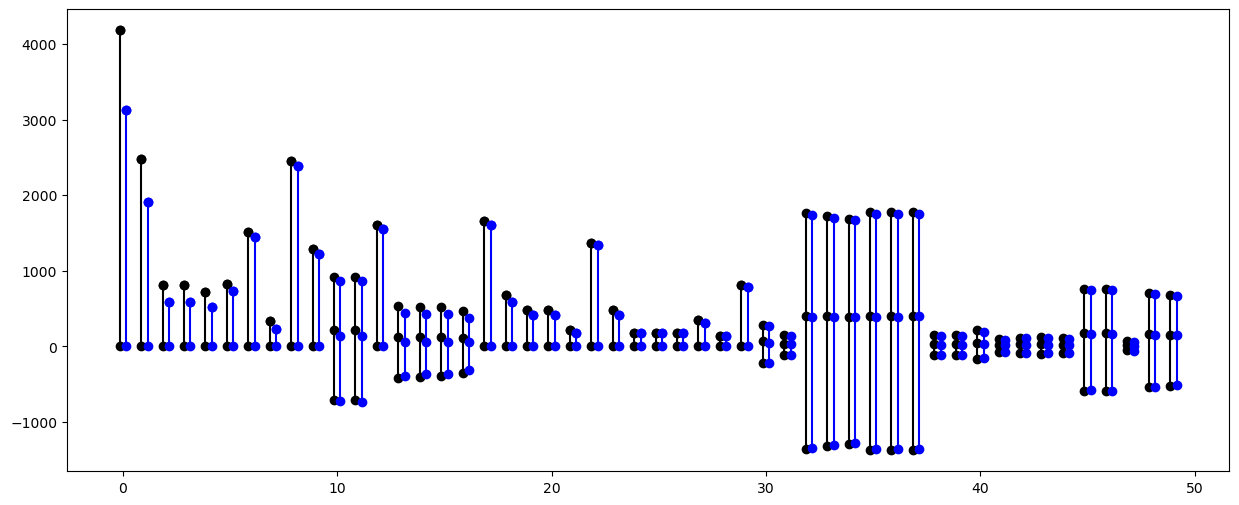

In [69]:
fig, ax = plt.subplots(1, 1, figsize=(15, 6))

shift = 0.15

sorting = ((rnp_charging_cost + rnp_discharging_revenue).sum() - (nat_charging_cost + nat_discharging_revenue).sum()).sort_values()

for i, col in enumerate(sorting.index[:50]):

    nat_costs = nat_charging_cost.loc[start:end, col].mul(1e-3)
    rnp_costs = rnp_charging_cost.loc[start:end, col].mul(1e-3)

    nat_revenue = nat_discharging_revenue.loc[start:end, col].mul(1e-3)
    rnp_revenue = rnp_discharging_revenue.loc[start:end, col].mul(1e-3)

    ax.plot([i-shift, i-shift], [nat_costs.sum(), nat_revenue.sum()], color='black', linestyle='-')
    ax.scatter(i-shift, nat_costs.sum(), color='black', marker='o')
    ax.scatter(i-shift, nat_revenue.sum(), color='black', marker='o')
    ax.scatter(i-shift, nat_costs.sum() + nat_revenue.sum(), color='black')

    ax.plot([i+shift, i+shift], [rnp_costs.sum(), rnp_revenue.sum()], color='blue', linestyle='-')
    ax.scatter(i+shift, rnp_costs.sum(), color='blue', marker='o')
    ax.scatter(i+shift, rnp_revenue.sum(), color='blue', marker='o')
    ax.scatter(i+shift, rnp_costs.sum() + rnp_revenue.sum(), color='blue')


plt.show()